In [115]:
import pandas as pd

df = pd.read_csv("Salary Data.csv")

In [116]:
print(df)

      Age  Gender Education Level                      Job Title  \
0    32.0    Male      Bachelor's              Software Engineer   
1    28.0  Female        Master's                   Data Analyst   
2    45.0    Male             PhD                 Senior Manager   
3    36.0  Female      Bachelor's                Sales Associate   
4    52.0    Male        Master's                       Director   
..    ...     ...             ...                            ...   
370  35.0  Female      Bachelor's       Senior Marketing Analyst   
371  43.0    Male        Master's         Director of Operations   
372  29.0  Female      Bachelor's         Junior Project Manager   
373  34.0    Male      Bachelor's  Senior Operations Coordinator   
374  44.0  Female             PhD        Senior Business Analyst   

     Years of Experience    Salary  
0                    5.0   90000.0  
1                    3.0   65000.0  
2                   15.0  150000.0  
3                    7.0   60000.0 

In [117]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [118]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [119]:
df.shape

(375, 6)

In [120]:
# Sort by Age
df_sorted = df.sort_values(by="Age", ascending=False)
print(df_sorted)

      Age  Gender Education Level                    Job Title  \
121  53.0    Male        Master's        Director of Marketing   
4    52.0    Male        Master's                     Director   
93   52.0  Female        Master's     Senior Marketing Manager   
83   52.0    Male             PhD     Chief Technology Officer   
158  51.0  Female             PhD  Director of Human Resources   
..    ...     ...             ...                          ...   
49   25.0    Male      Bachelor's            Help Desk Analyst   
27   24.0    Male      Bachelor's             Junior Developer   
114  23.0  Female      Bachelor's     Junior Marketing Analyst   
172   NaN     NaN             NaN                          NaN   
260   NaN     NaN             NaN                          NaN   

     Years of Experience    Salary  
121                 25.0  180000.0  
4                   20.0  200000.0  
93                  25.0  170000.0  
83                  24.0  250000.0  
158                 23

In [121]:
# Sorted salary
df_sorted = df.sort_values(by="Salary", ascending=True)
print(df_sorted)

      Age  Gender Education Level                              Job Title  \
259  29.0    Male      Bachelor's     Junior Business Operations Analyst   
82   25.0    Male      Bachelor's                   Sales Representative   
283  29.0  Female      Bachelor's  Junior Business Development Associate   
348  28.0  Female      Bachelor's              Junior Operations Manager   
189  28.0    Male      Bachelor's              Junior Operations Analyst   
..    ...     ...             ...                                    ...   
105  44.0    Male             PhD                     Chief Data Officer   
83   52.0    Male             PhD               Chief Technology Officer   
30   50.0    Male      Bachelor's                                    CEO   
172   NaN     NaN             NaN                                    NaN   
260   NaN     NaN             NaN                                    NaN   

     Years of Experience    Salary  
259                  1.5     350.0  
82           

In [122]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


In [123]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [124]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 325 entries, 0 to 371
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  324 non-null    float64
 1   Gender               324 non-null    object 
 2   Education Level      324 non-null    object 
 3   Job Title            324 non-null    object 
 4   Years of Experience  324 non-null    float64
 5   Salary               324 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.8+ KB


In [126]:
df.isnull().sum()        # missing values
df.dropna(inplace=True)  # remove

df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(df.isnull().sum())


Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


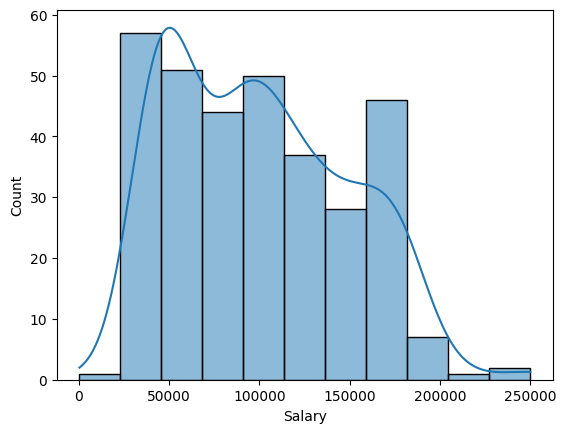

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Salary"], kde=True)
plt.show()

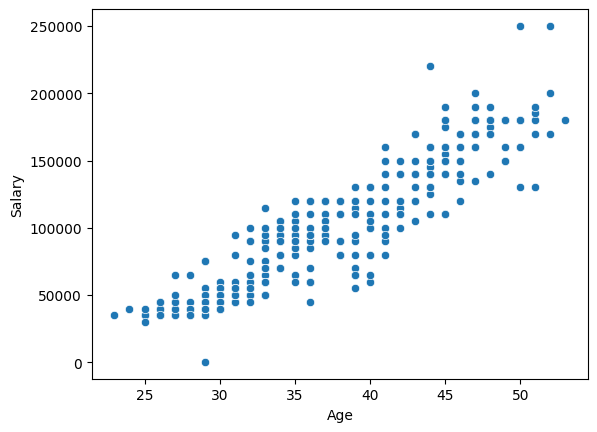

In [128]:
sns.scatterplot(x="Age", y="Salary", data=df)
plt.show()

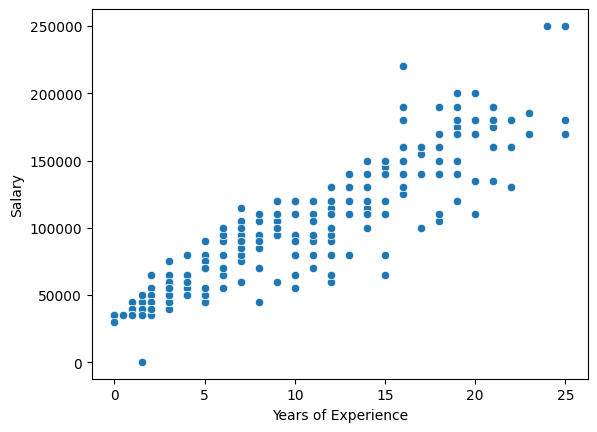

In [129]:
sns.scatterplot(x="Years of Experience", y="Salary", data=df)
plt.show()

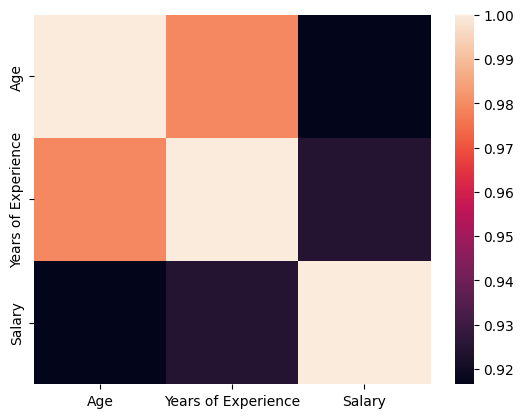

In [130]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=False)
plt.show()

In [131]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["Salary"] >= Q1 - 1.5*IQR) & (df["Salary"] <= Q3 + 1.5*IQR)]

In [132]:
print(df.head())
print(df.shape)

    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  
(324, 6)


In [133]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [134]:
# Experience Level
def exp_level(x):
    if x < 2:
        return "Fresher"
    elif x < 5:
        return "Junior"
    elif x < 10:
        return "Mid"
    else:
        return "Senior"

df["Experience_Level"] = df["Years of Experience"].apply(exp_level)

# Encoding
df = pd.get_dummies(df, columns=["Gender", "Education Level", "Job Title", "Experience_Level"], drop_first=True)

In [143]:
X = df.drop("Salary", axis=1)   # input features
y = df["Salary"]                # target

In [136]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [137]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [138]:
y_pred = model.predict(X_test)

In [139]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 12295.705324923872
R2 Score: 0.8694808745973437


In [140]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(result.head())

       Actual      Predicted
132  100000.0  113255.230394
108  100000.0  111977.813727
137   50000.0   70680.520774
9    110000.0  118831.639332
181  105000.0  109618.016354


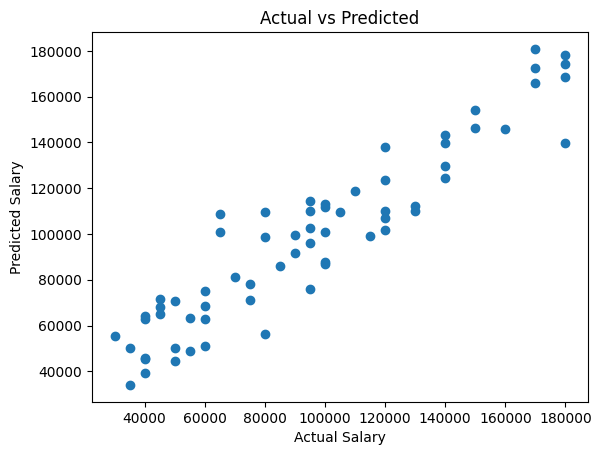

In [141]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

In [142]:
# Model coefficients
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print(coeff_df.sort_values(by="Coefficient", ascending=False))

                                                Coefficient
Job Title_CEO                                 108765.641598
Job Title_Chief Technology Officer             90110.787023
Job Title_Chief Data Officer                   86844.256125
Job Title_VP of Finance                        64297.765859
Job Title_Research Director                    54670.933155
...                                                     ...
Job Title_Recruiter                           -32144.087540
Job Title_Training Specialist                 -38083.898768
Job Title_Event Coordinator                   -38544.900598
Job Title_Administrative Assistant            -45975.726872
Job Title_Junior Business Operations Analyst  -48081.553789

[181 rows x 1 columns]
